## Computational Finance Lab Assignment 6
### Delta Hedging of a European Call Option
#### Aleksandra Górska, Marcin Pałyga


## Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import pandas as pd
sns.set_theme()

In [2]:
class DeltaHedging:
    def __init__(self, S0, K, T, r, sigma, N, M,
                 kappa=1.0, theta=0.04, xi=1.0, rho=-0.7, v0=0.04):
        self.S0 = S0
        self.K = K
        self.T = T
        self.r = r
        self.sigma = sigma
        self.N = N
        self.M = M
        self.kappa = kappa
        self.theta = theta
        self.xi = xi
        self.rho = rho
        self.v0 = v0
        self.dt = T / N
        self.times = np.linspace(0, T, N + 1)

    def bs_call(self, S, T, sigma):
        d1 = (np.log(S / self.K) + (self.r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return S * norm.cdf(d1) - self.K * np.exp(-self.r * T) * norm.cdf(d2)

    def bs_delta(self, S, T, sigma):
        d1 = (np.log(S / self.K) + (self.r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        return norm.cdf(d1)

    def simulate_bs(self):
        Z = np.random.standard_normal((self.M, self.N))
        W = np.cumsum(np.sqrt(self.dt) * Z, axis=1)
        W = np.hstack([np.zeros((self.M, 1)), W])
        S = self.S0 * np.exp(
            (self.r - 0.5 * self.sigma**2) * self.times + self.sigma * W
        )
        return S

    def simulate_heston(self):
        S = np.zeros((self.M, self.N + 1))
        v = np.zeros((self.M, self.N + 1))
        S[:, 0] = self.S0
        v[:, 0] = self.v0

        for i in range(self.N):
            Z1 = np.random.standard_normal(self.M)
            Z2 = np.random.standard_normal(self.M)
            dW1 = np.sqrt(self.dt) * Z1
            dW2 = np.sqrt(self.dt) * (self.rho * Z1 + np.sqrt(1 - self.rho**2) * Z2)
            v_pos = np.maximum(v[:, i], 0)
            v[:, i + 1] = (
                v[:, i]
                + self.kappa * (self.theta - v_pos) * self.dt
                + self.xi * np.sqrt(v_pos) * dW2
            )
            S[:, i + 1] = S[:, i] * np.exp(
                (self.r - 0.5 * v_pos) * self.dt + np.sqrt(v_pos) * dW1
            )
        return S, v

    def hedge_bs(self):
        S = self.simulate_bs()
        V = np.ones(self.M) * self.bs_call(self.S0, self.T, self.sigma)
        shares = np.zeros(self.M)

        for i in range(self.N):
            T = self.T - self.times[i]
            delta = self.bs_delta(S[:, i], T, self.sigma)
            if i > 0:
                V = V * np.exp(self.r * self.dt) + shares * (S[:, i] - S[:, i - 1] * np.exp(self.r * self.dt))
            shares = delta
        V = V * np.exp(self.r * self.dt) + shares * (S[:, i] - S[:, i - 1] * np.exp(self.r * self.dt))
        payoff = np.maximum(S[:, -1] - self.K, 0)
        return V - payoff

    def hedge_heston(self):
        S, v = self.simulate_heston()
        V = np.ones(self.M) * self.bs_call(self.S0, self.T, np.sqrt(self.v0))
        shares = np.zeros(self.M)

        for i in range(self.N):
            T = self.T - self.times[i]
            sigma_t = np.sqrt(np.maximum(v[:, i], 1e-8))
            delta = self.bs_delta(S[:, i], T, sigma_t)
            if i > 0:
                V = V * np.exp(self.r * self.dt) + shares * (S[:, i] - S[:, i - 1] * np.exp(self.r * self.dt))
            shares = delta
        V = V * np.exp(self.r * self.dt) + shares * (S[:, i] - S[:, i - 1] * np.exp(self.r * self.dt))
        payoff = np.maximum(S[:, -1] - self.K, 0)
        return V - payoff

    def stats(self, errors):
        return {
            "mean": np.mean(errors),
            "std": np.std(errors),
            "rmse": np.sqrt(np.mean(errors**2)),
            "mae": np.mean(np.abs(errors)),
            "p5": np.percentile(errors, 5),
            "p95": np.percentile(errors, 95),
        }


In [3]:
def error_statistics_df(results_dict):
    data = []
    for label, errors in results_dict.items():
        data.append({
            "Model": label,
            "Mean Error": np.mean(errors),
            "Std Error": np.std(errors),
            "RMSE": np.sqrt(np.mean(errors**2)),
            "Mean Abs Error": np.mean(np.abs(errors)),
            "5% Quantile": np.percentile(errors, 5),
            "95% Quantile": np.percentile(errors, 95),
        })
    df = pd.DataFrame(data)
    df.set_index("Model", inplace=True)
    return df

def plot_error_distribution(results_dict, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for label, errors in results_dict.items():
        axes[0].hist(errors, bins=50, alpha=0.6, density=True, label=label)
    axes[0].set_title(f"{title} – Distribution")
    axes[0].set_xlabel("Hedging Error")
    axes[0].set_ylabel("Density")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    labels = list(results_dict.keys())
    means = [np.mean(err) for err in results_dict.values()]
    stds = [np.std(err) for err in results_dict.values()]
    x = np.arange(len(labels))
    axes[1].bar(x, means, yerr=stds, capsize=5, alpha=0.7)
    axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=45)
    axes[1].set_ylabel("Mean Error ± Std")
    axes[1].set_title(f"{title} – Summary Statistics")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    return fig


## Part I: Delta Hedging under Black–Scholes Dynamics

,Mean Error,Std Error,RMSE,Mean Abs Error,5% Quantile,95% Quantile
Model,,,,,,
N=10,0.765962,7.717422,7.755340,5.301048,-11.954261,14.289369
N=50,0.132848,3.599994,3.602445,2.444566,-6.061123,6.557068
N=100,0.090581,2.585776,2.587362,1.742581,-4.345764,4.716368
N=252,0.068257,1.666427,1.667825,1.129430,-2.789435,2.985388


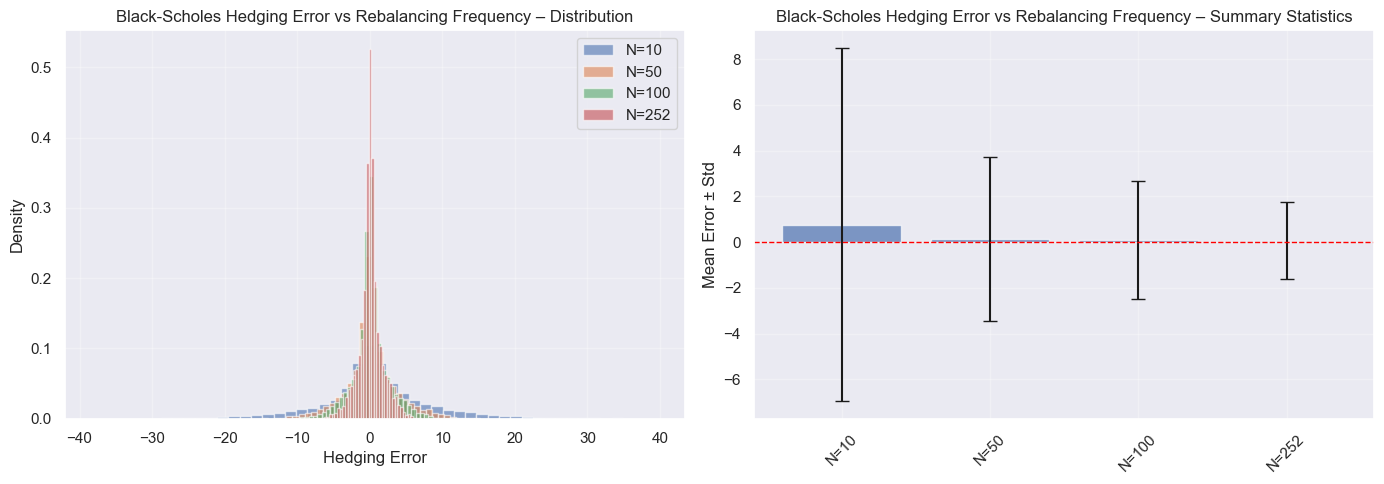

In [4]:
np.random.seed(42)
S0 = 100
K = 100
T = 1.0
r = 0.05
sigma = 0.2
M = 10_000
N_values = [10, 50, 100, 252]
bs_results = {}
for N in N_values:
    model = DeltaHedging(S0, K, T, r, sigma, N, M)
    errors = model.hedge_bs()
    bs_results[f"N={N}"] = errors

df_bs = error_statistics_df(bs_results)
display(df_bs)

fig1 = plot_error_distribution(
    bs_results,
    "Black-Scholes Hedging Error vs Rebalancing Frequency"
)

,Mean Error,Std Error,RMSE,Mean Abs Error,5% Quantile,95% Quantile
Model,,,,,,
σ=0.1,0.069544,1.851944,1.853249,1.334612,-3.098048,3.335478
σ=0.2,0.211625,3.612660,3.618853,2.454342,-5.996072,6.542965
σ=0.3,0.219523,5.570937,5.575260,3.618931,-9.382346,9.873468
σ=0.5,0.545610,10.525085,10.539217,6.165776,-15.996316,17.675218


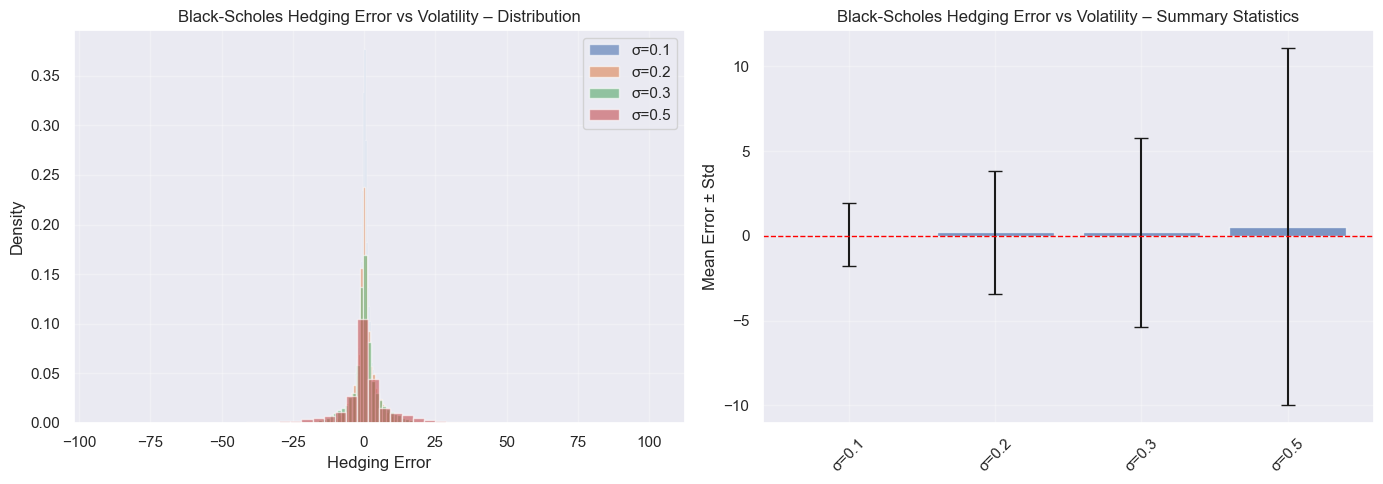

In [5]:
sigma_values = [0.1, 0.2, 0.3, 0.5]
N = 50
vol_results = {}

for sig in sigma_values:
    model = DeltaHedging(S0, K, T, r, sig, N, M)
    errors = model.hedge_bs()
    vol_results[f"σ={sig}"] = errors

df_vol = error_statistics_df(vol_results)
display(df_vol)

fig2 = plot_error_distribution(
    vol_results,
    "Black-Scholes Hedging Error vs Volatility"
)

## Part II: Delta Hedging under Stochastic Volatility

,Mean Error,Std Error,RMSE,Mean Abs Error,5% Quantile,95% Quantile
Model,,,,,,
Stoch Vol (ξ=1.0),1.569615,4.968037,5.210095,4.211972,-9.183859,6.352001
Stoch Vol (ξ=0.1),0.101822,3.481181,3.482670,2.486760,-5.592745,6.153157
Black-Scholes,0.090585,3.741485,3.742581,2.533947,-6.439583,6.653965


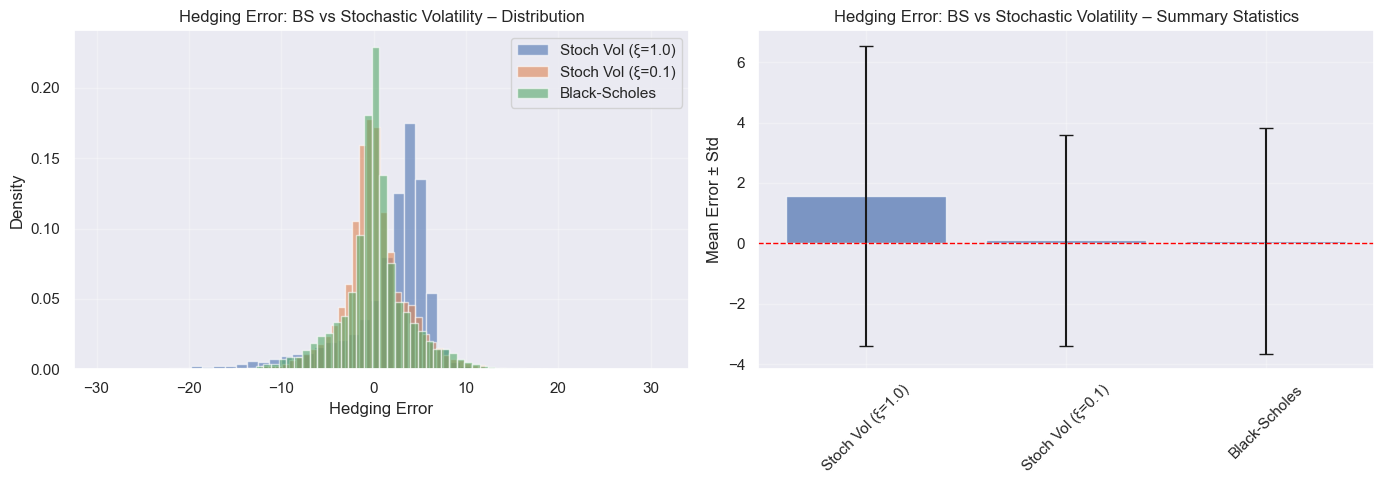

In [6]:
sv_results = {}

model_sv_high = DeltaHedging(
    S0, K, T, r, sigma, N, M,
    xi=1.0, theta=0.04, v0=0.04
)
sv_results["Stoch Vol (ξ=1.0)"] = model_sv_high.hedge_heston()

model_sv_low = DeltaHedging(
    S0, K, T, r, sigma, N, M,
    xi=0.1, theta=0.04, v0=0.04
)
sv_results["Stoch Vol (ξ=0.1)"] = model_sv_low.hedge_heston()

model_bs = DeltaHedging(S0, K, T, r, sigma, N, M)
sv_results["Black-Scholes"] = model_bs.hedge_bs()

df_sv = error_statistics_df(sv_results)
display(df_sv)

fig3 = plot_error_distribution(
    sv_results,
    "Hedging Error: BS vs Stochastic Volatility"
)

## Discussion questions

1. Why does the delta hedging perform differently under the constant and stochastic volatility with a relatively large $\xi$?

Delta hedging works well in constant-volatility markets because price risk is the only source of uncertainty. In stochastic-volatility markets, especially when $\xi$ is large, option values are strongly affected by unhedgeable volatility risk, which delta hedging cannot remove.

2. Why does the delta hedging perform similarly under the constant and stochastic volatility with a relatively small $\xi$?

When $\xi$ is small, stochastic volatility behaves almost like constant volatility, so delta hedging performs similarly in both settings.

3. Which market risks are not hedged by the delta alone? How could you hedge them?

Delta hedging alone cannot hedge volatility or model risk i.e. flaws or misaccuracy of models used to price derivatives. These require adding additional options or using more consistent models.